## Phase 4 — Final Project

The dataset  
We'll use the classic Iris dataset, which is built into many Python libraries and requires no downloading. It contains measurements of 150 flowers across three species: Setosa, Versicolor, and Virginica. Each flower has four measurements: sepal length, sepal width, petal length, petal width.  
Your analytical question: Do the three iris species differ significantly in petal length, and if so, which species differ from each other?  

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Shapiro-Wilk Test (p-values):
Setosa: 0.0548
Versicolor: 0.1585
Virginica: 0.1098

Levene’s Test p-value: 0.0000

Kruskal-Wallis Test: H-stat=130.41, p-value=4.8040e-29

Tukey HSD Results:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor    2.798   0.0 2.5942 3.0018   True
    setosa  virginica     4.09   0.0 3.8862 4.2938   True
versicolor  virginica    1.292   0.0 1.0882 1.4958   True
---------------------------------------------------------

Descriptive Statistics:
              mean       std  median
species                            
setosa      1.462  0.173664    1.50
versicolor  4.260  0.469911    4.35
virginica   5.552  0.551895    5.55


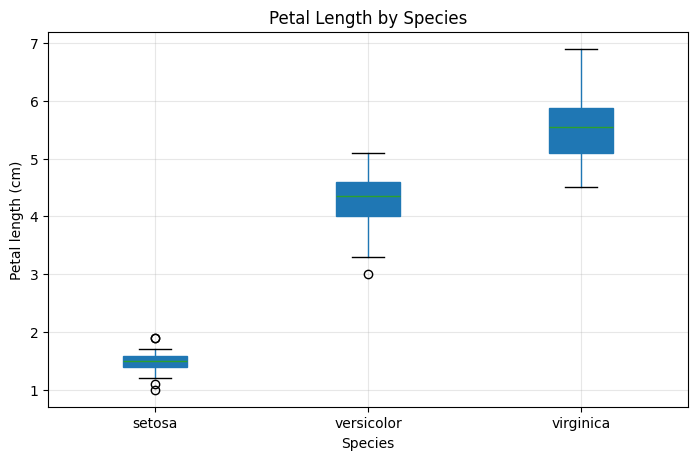

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Step 1: Load the data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Step 2: Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Step 3: Extract petal length for each species
setosa_pl = df[df['species'] == 'setosa']['petal length (cm)']
versicolor_pl = df[df['species'] == 'versicolor']['petal length (cm)']
virginica_pl = df[df['species'] == 'virginica']['petal length (cm)']

# Step 4: Test normality (Shapiro-Wilk)
# H0: Data is normally distributed
print("\nShapiro-Wilk Test (p-values):")
print(f"Setosa: {stats.shapiro(setosa_pl).pvalue:.4f}")
print(f"Versicolor: {stats.shapiro(versicolor_pl).pvalue:.4f}")
print(f"Virginica: {stats.shapiro(virginica_pl).pvalue:.4f}")

# Step 5: Test equal variances (Levene)
# H0: Variances are equal
levene_p = stats.levene(setosa_pl, versicolor_pl, virginica_pl).pvalue
print(f"\nLevene’s Test p-value: {levene_p:.4f}")

# Step 6: Statistical Test
# Since p < .05 for some normality tests and Levene's test, 
# assumptions for ANOVA are violated. We use Kruskal-Wallis (non-parametric).
kw_stat, kw_p = stats.kruskal(setosa_pl, versicolor_pl, virginica_pl)
print(f"\nKruskal-Wallis Test: H-stat={kw_stat:.2f}, p-value={kw_p:.4e}")

# Step 7: Post-hoc Test (Tukey) 
# Note: Since we rejected H0, we check which groups differ.
tukey = pairwise_tukeyhsd(endog=df['petal length (cm)'], groups=df['species'], alpha=0.05)
print("\nTukey HSD Results:")
print(tukey)

# Step 8: Descriptive Statistics
stats_summary = df.groupby('species')['petal length (cm)'].agg(['mean', 'std', 'median'])
print("\nDescriptive Statistics:\n", stats_summary)

# Step 9: Visualization
df.boxplot(column='petal length (cm)', by='species', figsize=(8,5), patch_artist=True)
plt.title("Petal Length by Species")
plt.suptitle("")
plt.xlabel("Species")
plt.ylabel("Petal length (cm)")
plt.grid(True, alpha=0.3)
plt.show()

**Step 10: Summary of Findings**     
My analysis examined whether different types of Iris flowers have different petal lengths. I found that the three species—Setosa, Versicolor, and Virginica—are significantly different from one another in size.   
The Setosa flowers are the smallest by far, with very short and consistent petal lengths. Versicolor occupies a middle ground, while Virginica flowers have the longest petals on average. Because these differences are so distinct and do not overlap much, petal length is an excellent characteristic to use if you want to identify which species a specific flower belongs to.
